In [0]:
from pyspark.sql import SparkSession
spark =SparkSession.builder.appName("People_data_analysis").getOrCreate()
df_people=spark.read.parquet('/Volumes/movie_catalog/movie_schema/temp_storage/people_data')
df_people.printSchema()
df_people.show()

root
 |-- id: integer (nullable = true)
 |-- firstName: string (nullable = true)
 |-- middleName: string (nullable = true)
 |-- lastName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- ssn: string (nullable = true)
 |-- salary: double (nullable = true)

+-------+----------+----------+---------+------+----+-----------+--------+
|     id| firstName|middleName| lastName|gender| age|        ssn|  salary|
+-------+----------+----------+---------+------+----+-----------+--------+
|4414361|     Debbi|    Simona|   Skewes|     F|47.0|666-10-1027| 32718.0|
|2773469|   Arvilla|   Coralie|   Flight|     F|38.0|666-10-1035|111156.0|
|3934080|  Shalanda|Jacquiline|  Gellett|     F|51.0|666-10-1128| 84680.0|
| 579211|      Mimi|     Marla|  Kinkade|     F|61.0|666-10-1210| 54054.0|
|1684762|    Eladia|     Maira|  Choppin|     F|52.0|666-10-1230| 79032.0|
|6474856|     Frank|   Edwardo|  Mallord|     M|32.0|666-10-1287| 55079.0|
|2255416|  Rhia

In [0]:
df_people.groupby('gender').count().show()

+------+-------+
|gender|  count|
+------+-------+
|     M|4496869|
|     F|4847972|
+------+-------+



In [0]:
df_people.groupby('gender').sum('salary').show(truncate=False)

+------+-----------------+
|gender|sum(salary)      |
+------+-----------------+
|M     |3.265467281555E11|
|F     |3.520821728615E11|
+------+-----------------+



In [0]:
df_people.groupby('gender').sum('salary').withColumnRenamed('sum(salary)',"Sum of Salary").show()

+------+-----------------+
|gender|    Sum of Salary|
+------+-----------------+
|     M|3.265467281555E11|
|     F|3.520821728615E11|
+------+-----------------+



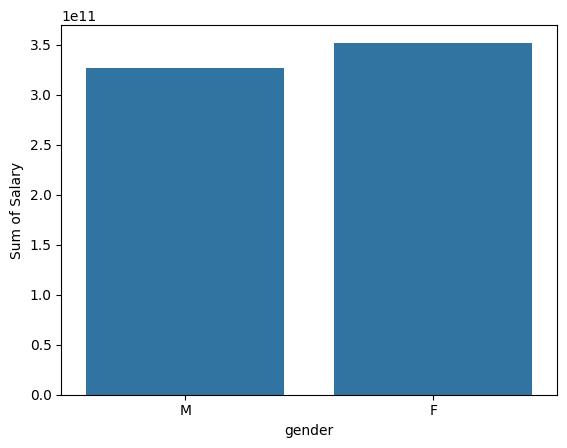

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
df_people_pd =df_people.groupby('gender').sum('salary').withColumnRenamed('sum(salary)',"Sum of Salary").toPandas()
sns.barplot(x=df_people_pd["gender"],y=df_people_pd["Sum of Salary"])
plt.show()

In [0]:
from pyspark.sql.functions import col
df_people.groupby("age").\
                    sum("salary").\
                    withColumnRenamed("sum(salary)","Sum Of Salary").\
                        orderBy("age").\
                        withColumn("Sum Of Salary",col("Sum Of Salary")/100000).show()

+----+-------------+
| age|Sum Of Salary|
+----+-------------+
|26.0|  89823.76039|
|27.0|149483.142845|
|28.0| 149255.87681|
|29.0|149024.065455|
|30.0| 148598.51178|
|31.0| 148024.69582|
|32.0|147194.651135|
|33.0|147346.250555|
|34.0|147222.978185|
|35.0|146539.692005|
|36.0| 146054.31985|
|37.0| 145474.22634|
|38.0| 145585.15169|
|39.0|  144959.6185|
|40.0| 144456.46398|
|41.0| 144414.61668|
|42.0|  143891.7194|
|43.0| 144032.52182|
|44.0|142833.066045|
|45.0| 142694.27773|
+----+-------------+
only showing top 20 rows


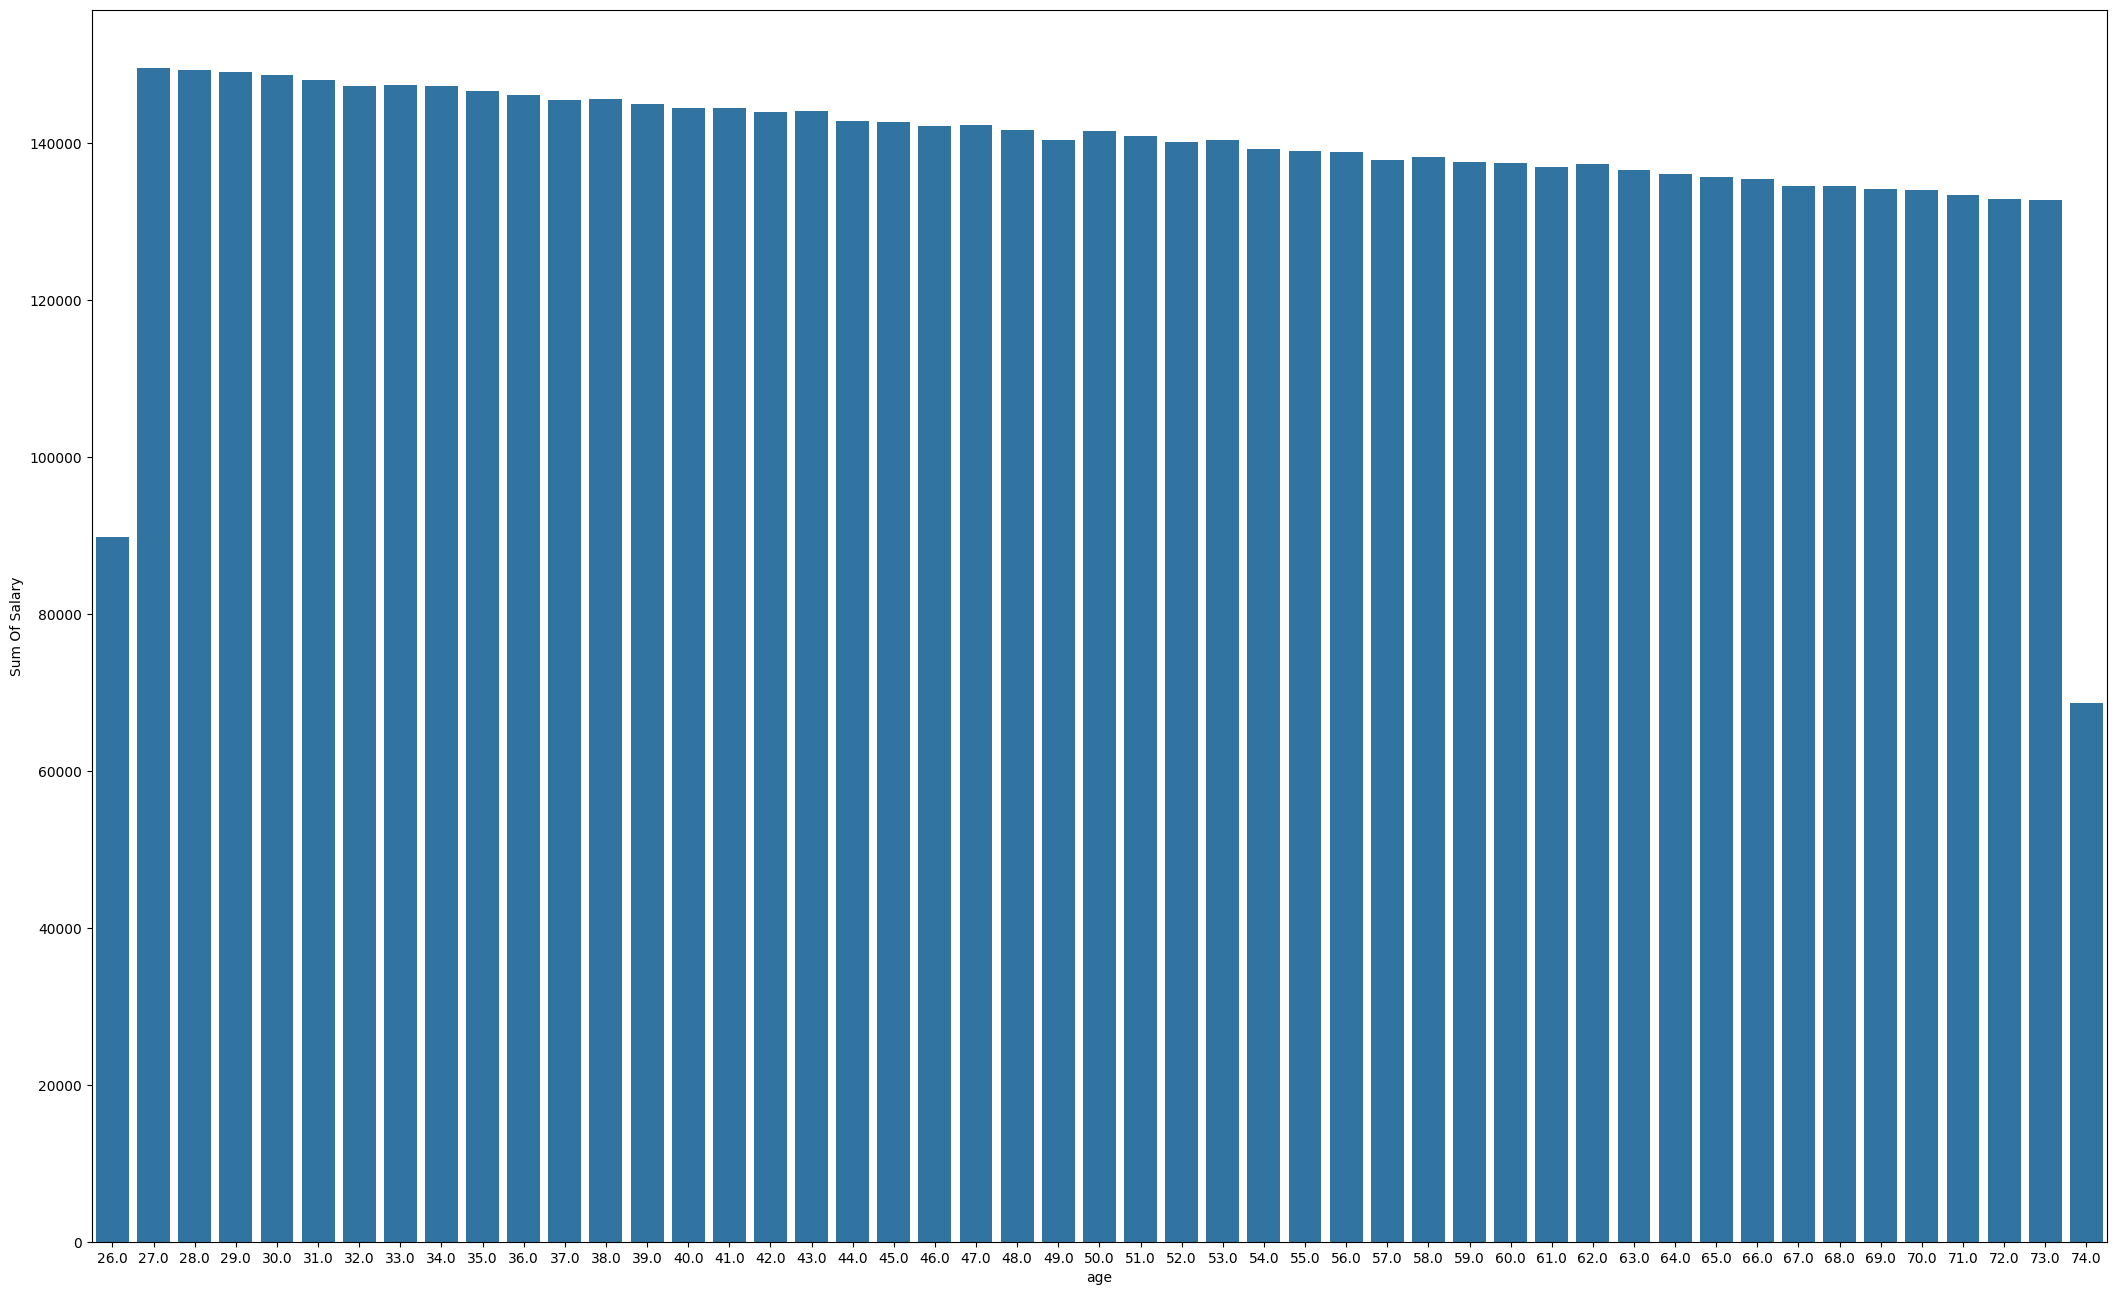

In [0]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
plt.figure(figsize=(26,16))
import seaborn as sns
df_people_pd=df_people.groupby("age").\
                    sum("salary").\
                    withColumnRenamed("sum(salary)","Sum Of Salary").\
                        orderBy("age").\
                        withColumn("Sum Of Salary",col("Sum Of Salary")/100000).\
                        toPandas()

sns.barplot(x=df_people_pd["age"],y=df_people_pd["Sum Of Salary"])
plt.show()

In [0]:
df_people.printSchema()

root
 |-- id: integer (nullable = true)
 |-- firstName: string (nullable = true)
 |-- middleName: string (nullable = true)
 |-- lastName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- ssn: string (nullable = true)
 |-- salary: double (nullable = true)



In [0]:
from pyspark.sql.functions import daysofweek
df_people.withColumn("DayOfWeek",days
                     )